In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('StudentsPerformance.csv')
print('Shape:', df.shape)
df.head()

Saving StudentsPerformance.csv to StudentsPerformance.csv
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


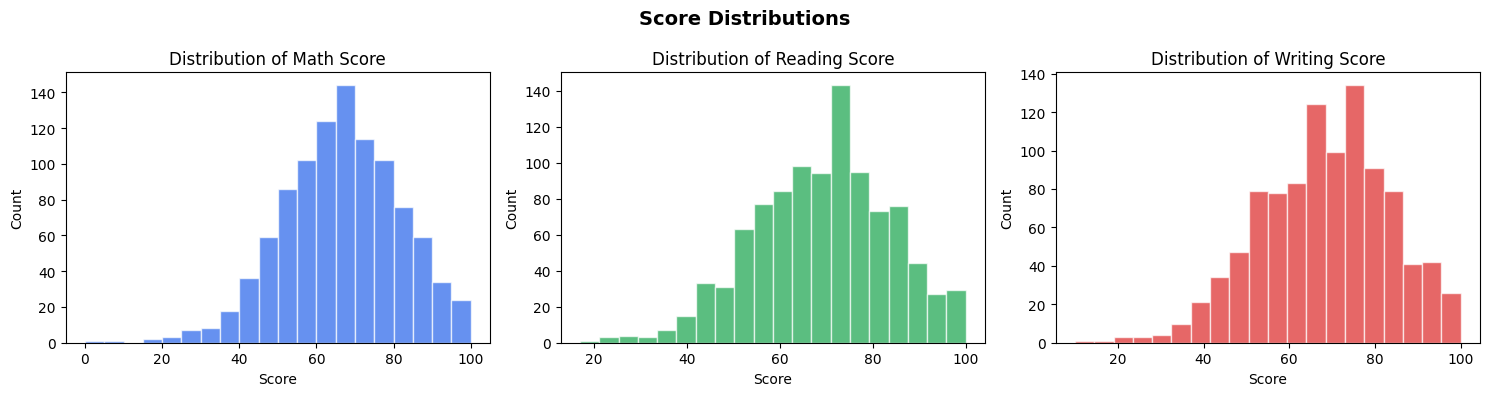

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
score_cols = ['math score', 'reading score', 'writing score']
colors = ['#2563eb', '#16a34a', '#dc2626']

for ax, col, color in zip(axes, score_cols, colors):
    ax.hist(df[col], bins=20, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'Distribution of {col.title()}', fontsize=12)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

plt.suptitle('Score Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

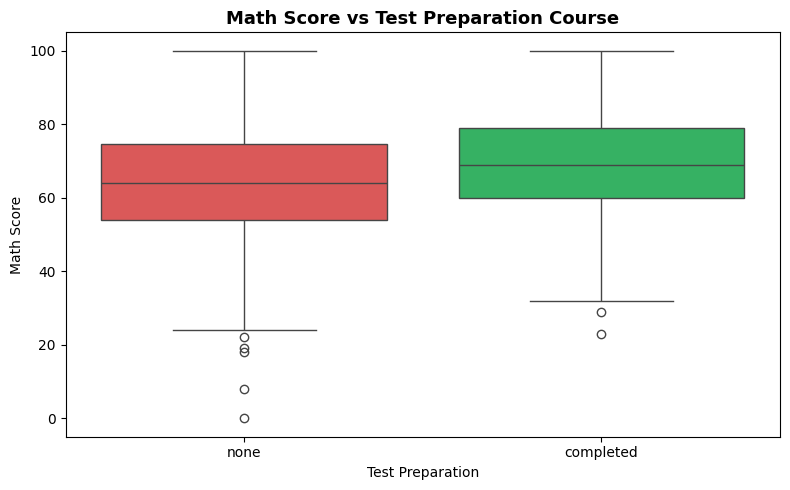

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='test preparation course', y='math score', palette=['#ef4444','#22c55e'])
plt.title('Math Score vs Test Preparation Course', fontsize=13, fontweight='bold')
plt.xlabel('Test Preparation')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('test_prep_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Check exact column names first
print("Columns:", df.columns.tolist())

# Create average score as target
df['average score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Encode categorical columns
le = LabelEncoder()
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

for col in cat_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

print('Encoded columns created:')
print([c for c in df.columns if '_encoded' in c])

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
Encoded columns created:
['gender_encoded', 'race/ethnicity_encoded', 'parental level of education_encoded', 'lunch_encoded', 'test preparation course_encoded']


In [8]:
# Prepare features and target
feature_cols = [col for col in df.columns if '_encoded' in col]
X = df[feature_cols]
y = df['average score']

print("Features used:", feature_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Features used: ['gender_encoded', 'race/ethnicity_encoded', 'parental level of education_encoded', 'lunch_encoded', 'test preparation course_encoded']
Training samples: 800
Testing samples:  200


In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'RMSE': round(rmse, 3), 'R2': round(r2, 3)}
    print(f'{name:22s} | RMSE: {rmse:.3f} | R²: {r2:.3f}')

Linear Regression      | RMSE: 13.691 | R²: 0.126
Decision Tree          | RMSE: 15.309 | R²: -0.093
Random Forest          | RMSE: 14.849 | R²: -0.029


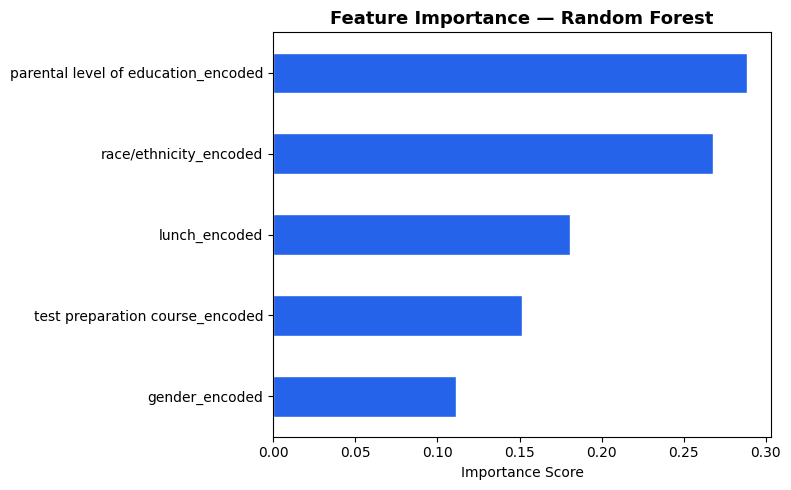

In [10]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#2563eb', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
results_df = pd.DataFrame(results).T
print('\n===== Model Comparison =====')
print(results_df)
best = results_df['R2'].idxmax()
print(f'\nBest Model: {best} with R² = {results_df.loc[best, "R2"]}')


===== Model Comparison =====
                     RMSE     R2
Linear Regression  13.691  0.126
Decision Tree      15.309 -0.093
Random Forest      14.849 -0.029

Best Model: Linear Regression with R² = 0.126
